In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("Thales_Group_Manufacturing.csv")

In [7]:
df.head()

df.tail()

df.shape

df.info()

df.describe()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  object 
 1   Timestamp                      100000 non-null  object 
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  object 
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 non-null  float64
 7   Network_Latency_ms             100000 non-null  float64
 8   Packet_Loss_%                  100000 non-null  float64
 9   Quality_Control_Defect_Rate_%  100000 non-null  float64
 10  Production_Speed_units_per_hr  100000 non-null  float64
 11  Predictive_Maintenance_Score   100000 non-null  float64
 12  Error_Rate_%                   

Index(['Date', 'Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
Date,0
Timestamp,0
Machine_ID,0
Operation_Mode,0
Temperature_C,0
Vibration_Hz,0
Power_Consumption_kW,0
Network_Latency_ms,0
Packet_Loss_%,0
Quality_Control_Defect_Rate_%,0


In [9]:
df.fillna(method='ffill', inplace=True)

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)


In [13]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Timestamp'],
    dayfirst=True
)

In [14]:
df.sort_values("Datetime", inplace=True)

In [15]:
df.shape

(100000, 15)

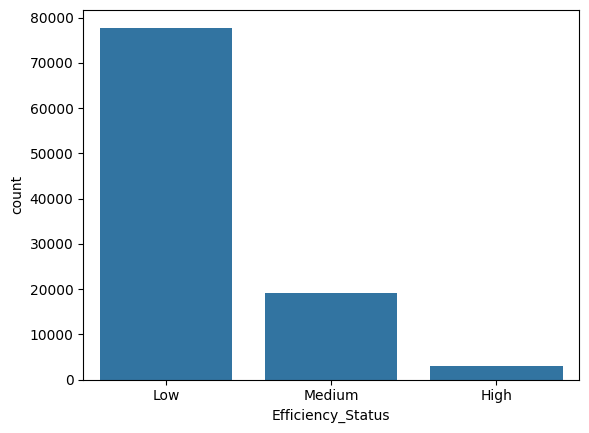

In [16]:
sns.countplot(x='Efficiency_Status', data=df)
plt.show()

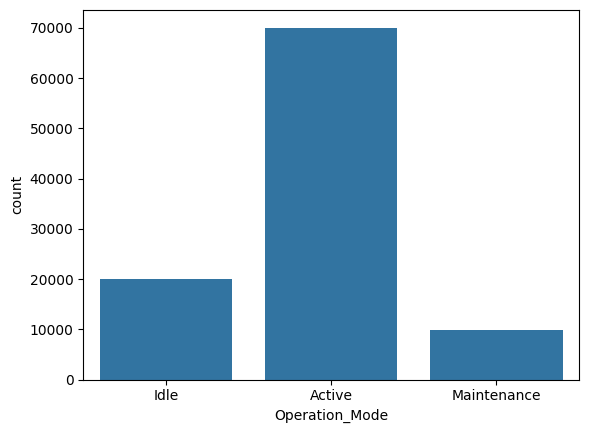

In [17]:
sns.countplot(x='Operation_Mode', data=df)
plt.show()

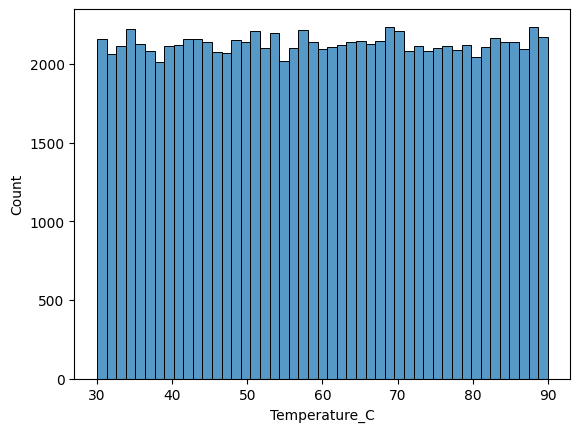

In [18]:
sns.histplot(df['Temperature_C'])
plt.show()

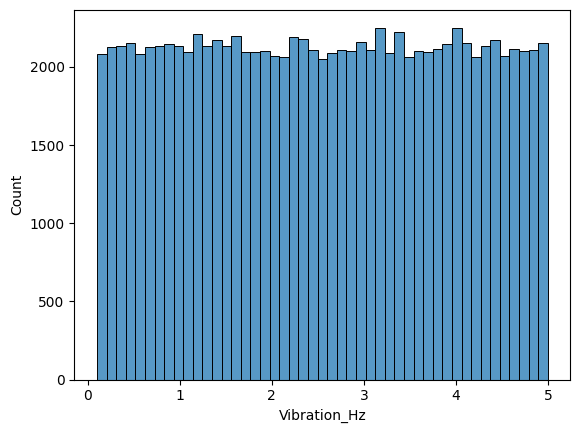

In [19]:
sns.histplot(df['Vibration_Hz'])
plt.show()

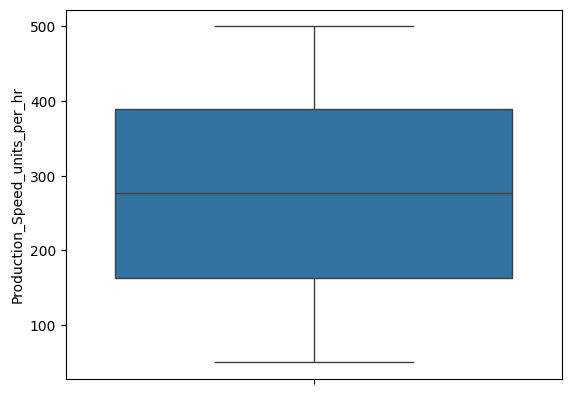

In [20]:
sns.boxplot(y=df['Production_Speed_units_per_hr'])
plt.show()

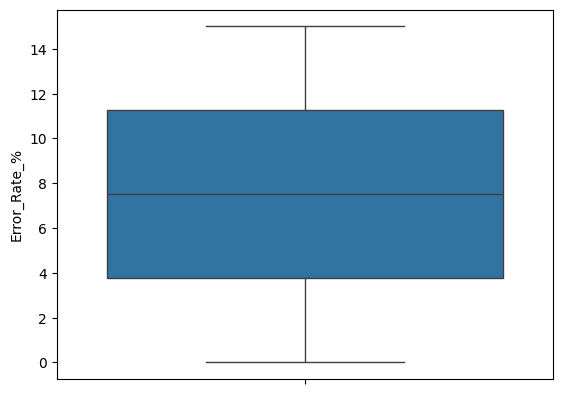

In [21]:
sns.boxplot(y=df['Error_Rate_%'])
plt.show()

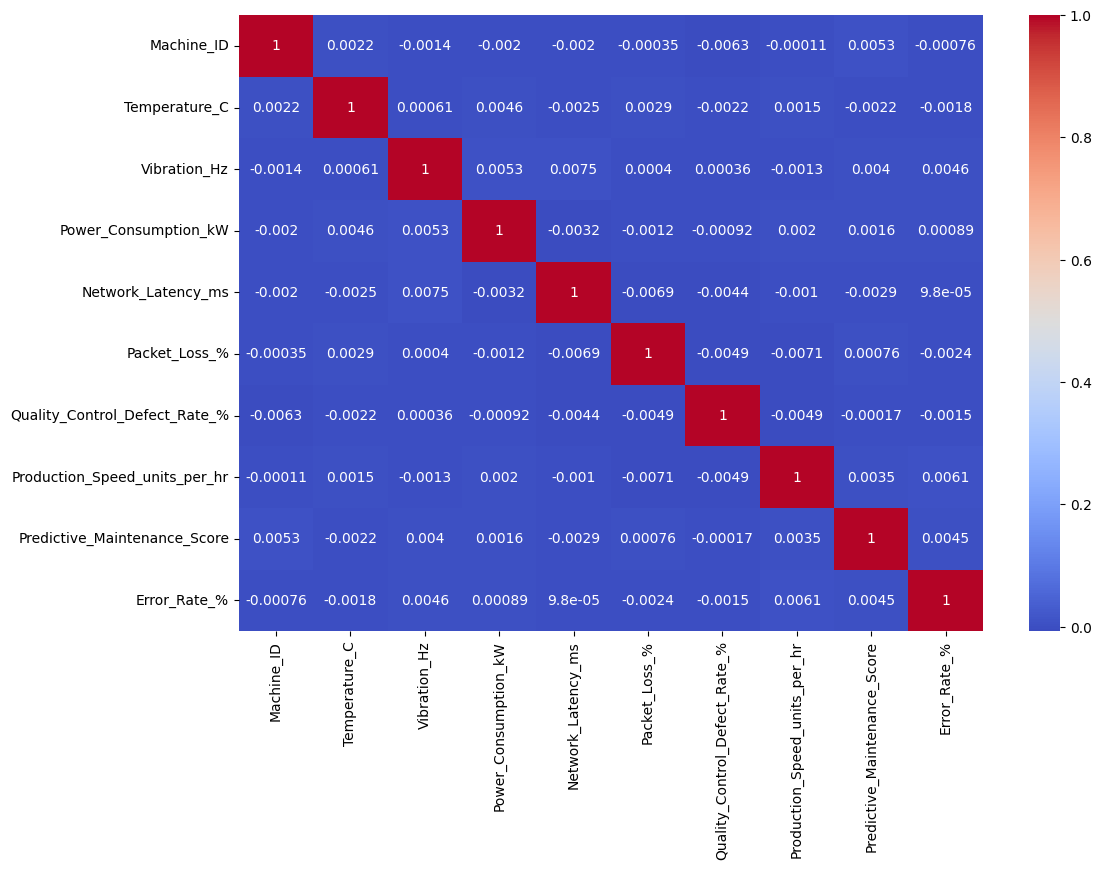

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [23]:
df["Energy_Efficiency"] = df["Production_Speed_units_per_hr"] / df["Power_Consumption_kW"]

In [24]:
df["Error_Output_Ratio"] = df["Error_Rate_%"] / df["Production_Speed_units_per_hr"]

In [25]:
df["Network_Reliability"] = 100 - (df["Packet_Loss_%"] + df["Network_Latency_ms"]/10)

In [26]:
df["Sensor_Stability"] = (
    df["Temperature_C"] +
    df["Vibration_Hz"]
) / 2

In [27]:
le_machine = LabelEncoder()

df["Machine_ID"] = le_machine.fit_transform(df["Machine_ID"])

In [28]:
le_mode = LabelEncoder()

df["Operation_Mode"] = le_mode.fit_transform(df["Operation_Mode"])

In [29]:
le_target = LabelEncoder()

df["Efficiency_Status"] = le_target.fit_transform(df["Efficiency_Status"])

In [30]:
X = df.drop(
    ["Efficiency_Status",
     "Date",
     "Timestamp",
     "Datetime"],
     axis=1
)

y = df["Efficiency_Status"]

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [33]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred1 = lr.predict(X_test)

accuracy_score(y_test,pred1)

0.91945

In [34]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred2 = rf.predict(X_test)

accuracy_score(y_test,pred2)

0.99995

In [35]:
gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

pred3 = gb.predict(X_test)

accuracy_score(y_test,pred3)

1.0

<Axes: >

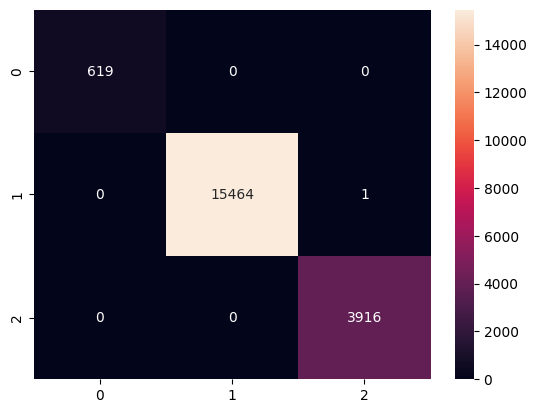

In [36]:
cm = confusion_matrix(y_test,pred2)

sns.heatmap(cm,
            annot=True,
            fmt="d")

In [37]:
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       619
           1       1.00      1.00      1.00     15465
           2       1.00      1.00      1.00      3916

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [38]:
importance = rf.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

feature_df.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
10,Error_Rate_%,0.385623
12,Error_Output_Ratio,0.307903
8,Production_Speed_units_per_hr,0.229788
11,Energy_Efficiency,0.056138
4,Power_Consumption_kW,0.009701
7,Quality_Control_Defect_Rate_%,0.001310
9,Predictive_Maintenance_Score,0.001285
5,Network_Latency_ms,0.001245
13,Network_Reliability,0.001237
6,Packet_Loss_%,0.001228


<Axes: xlabel='Importance', ylabel='Feature'>

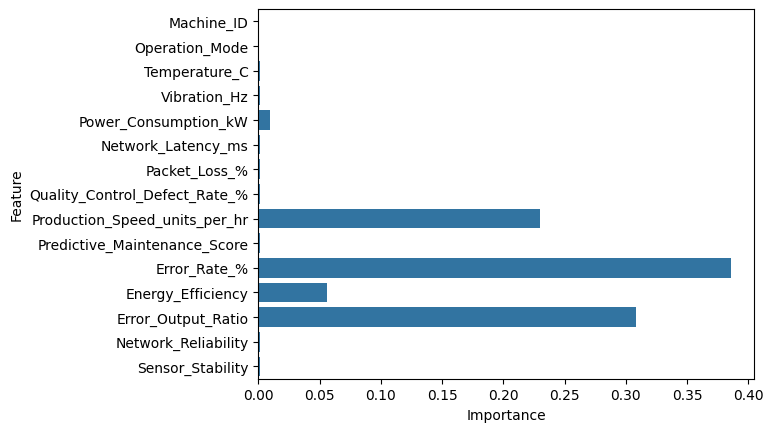

In [39]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

In [40]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print(prediction)

[1]


In [41]:
import joblib

joblib.dump(rf,"manufacturing_model.pkl")

['manufacturing_model.pkl']

In [42]:
feature_df.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
10,Error_Rate_%,0.385623
12,Error_Output_Ratio,0.307903
8,Production_Speed_units_per_hr,0.229788
11,Energy_Efficiency,0.056138
4,Power_Consumption_kW,0.009701
7,Quality_Control_Defect_Rate_%,0.001310
9,Predictive_Maintenance_Score,0.001285
5,Network_Latency_ms,0.001245
13,Network_Reliability,0.001237
6,Packet_Loss_%,0.001228


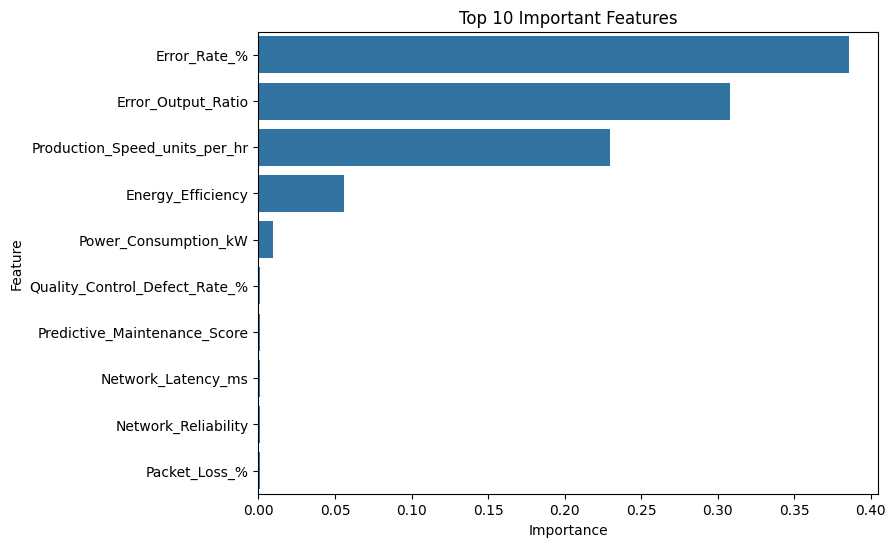

In [43]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_df.sort_values(by="Importance", ascending=False).head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

In [44]:
# Before scaling
X_train_df = X_train.copy()
X_test_df = X_test.copy()

# Scale
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
sample = X_test[:5]        # Scaled data for prediction
predictions = rf.predict(sample)

print("Predictions:")
print(le_target.inverse_transform(predictions))

Predictions:
['Low' 'Low' 'Low' 'Low' 'Low']


In [46]:
predictions = le_target.inverse_transform(predictions)
print(predictions)

['Low' 'Low' 'Low' 'Low' 'Low']


In [47]:
import joblib

joblib.dump(rf, "manufacturing_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [48]:
%%writefile app.py

import streamlit as st

st.set_page_config(page_title="Manufacturing Efficiency Dashboard")

st.title("🏭 Manufacturing Efficiency Prediction")

st.write("Your Streamlit application goes here.")

Writing app.py


In [49]:
import joblib

joblib.dump(le_target, "label_encoder.pkl")

['label_encoder.pkl']

In [50]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn

Writing requirements.txt


In [51]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.9 MB/s eta 0:00:00


In [52]:
from reportlab.pdfgen import canvas

c = canvas.Canvas("Project_Report.pdf")

c.drawString(100,800,"Manufacturing Efficiency Prediction")
c.drawString(100,780,"Machine Learning Project Report")

c.drawString(100,740,"Objective:")
c.drawString(100,720,"Predict machine efficiency using Machine Learning.")

c.drawString(100,680,"Models Used:")
c.drawString(100,660,"Random Forest")
c.drawString(100,640,"Logistic Regression")
c.drawString(100,620,"Gradient Boosting")

c.drawString(100,580,"Dataset:")
c.drawString(100,560,"Thales_Group_Manufacturing.csv")

c.drawString(100,520,"Conclusion:")
c.drawString(100,500,"Random Forest produced the best performance.")

c.save()

In [53]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.1 MB/s eta 0:00:00


In [54]:
from pptx import Presentation

prs = Presentation()

slide = prs.slides.add_slide(prs.slide_layouts[0])

slide.shapes.title.text = "Manufacturing Efficiency Prediction"

slide.placeholders[1].text = "Machine Learning Project"

prs.save("Presentation.pptx")

In [55]:
%cd /content/Manufacturing_Efficiency_Project

[Errno 2] No such file or directory: '/content/Manufacturing_Efficiency_Project'
/content


In [56]:
!ls

 Presentation.pptx    Thales_Group_Manufacturing.csv
 Project_Report.pdf  'Thales_Manufacturing_Efficiency_Classification (2).ipynb'
 sample_data


In [57]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 66.2 MB/s eta 0:00:00


In [58]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [59]:
!mkdir /content/Manufacturing_Efficiency_Project

In [60]:
!mv "/content/Thales_Group_Manufacturing.csv" "/content/Manufacturing_Efficiency_Project/"
!mv "/content/Project_Report.pdf" "/content/Manufacturing_Efficiency_Project/"
!mv "/content/Presentation.pptx" "/content/Manufacturing_Efficiency_Project/"
!mv "/content/Thales_Manufacturing_Efficiency_Classification (2).ipynb" "/content/Manufacturing_Efficiency_Project/Manufacturing_Project.ipynb"

In [61]:
%cd /content/Manufacturing_Efficiency_Project

/content/Manufacturing_Efficiency_Project


In [62]:
!ls

Manufacturing_Project.ipynb  Project_Report.pdf
Presentation.pptx	     Thales_Group_Manufacturing.csv


In [63]:
%cd /content/Manufacturing_Efficiency_Project

/content/Manufacturing_Efficiency_Project


In [64]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


# Page Configuration
st.set_page_config(
    page_title="Manufacturing Efficiency Dashboard",
    page_icon="🏭",
    layout="wide"
)


st.title("🏭 Manufacturing Efficiency Prediction Dashboard")

st.write(
    "Machine Learning based Manufacturing Efficiency Prediction System"
)


# Load Dataset and Model Files

data = pd.read_csv("Thales_Group_Manufacturing.csv")

model = joblib.load("manufacturing_model.pkl")

scaler = joblib.load("scaler.pkl")

label_encoder = joblib.load("label_encoder.pkl")


# Sidebar Menu

menu = st.sidebar.selectbox(
    "Navigation",
    [
        "Home",
        "Dataset",
        "Visualization",
        "Prediction",
        "Model"
    ]
)


# Home Page

if menu == "Home":

    st.header("Project Overview")

    st.write("""
    This project predicts manufacturing machine efficiency
    using Machine Learning.

    The model predicts:

    - High Efficiency
    - Medium Efficiency
    - Low Efficiency

    The system uses manufacturing sensor data such as:

    - Temperature
    - Vibration
    - Power Consumption
    - Production Speed
    - Error Rate
    - Maintenance Score
    """)



# Dataset Page

elif menu == "Dataset":

    st.header("Manufacturing Dataset")

    st.dataframe(data.head())

    st.write("Dataset Shape:")
    st.write(data.shape)

    st.write("Dataset Columns:")
    st.write(list(data.columns))



# Visualization Page

elif menu == "Visualization":

    st.header("Efficiency Status Distribution")

    fig, ax = plt.subplots(figsize=(8,5))

    sns.countplot(
        data=data,
        x="Efficiency_Status",
        ax=ax
    )

    ax.set_title(
        "Machine Efficiency Distribution"
    )

    st.pyplot(fig)



# Prediction Page

elif menu == "Prediction":

    st.header("Predict Machine Efficiency")


    machine_id = st.number_input(
        "Machine ID",
        value=0
    )

    operation_mode = st.number_input(
        "Operation Mode",
        value=0
    )

    temperature = st.number_input(
        "Temperature (°C)"
    )

    vibration = st.number_input(
        "Vibration (Hz)"
    )

    power = st.number_input(
        "Power Consumption (kW)"
    )

    latency = st.number_input(
        "Network Latency (ms)"
    )

    packet_loss = st.number_input(
        "Packet Loss (%)"
    )

    defect_rate = st.number_input(
        "Quality Defect Rate (%)"
    )

    production_speed = st.number_input(
        "Production Speed"
    )

    maintenance_score = st.number_input(
        "Maintenance Score"
    )

    error_rate = st.number_input(
        "Error Rate (%)"
    )


    # Feature Engineering

    energy_efficiency = (
        production_speed / power
        if power != 0 else 0
    )

    error_output_ratio = (
        error_rate / production_speed
        if production_speed != 0 else 0
    )

    network_reliability = (
        100 - (packet_loss + latency/10)
    )

    sensor_stability = (
        temperature + vibration
    ) / 2



    input_data = pd.DataFrame({

        "Machine_ID":[machine_id],

        "Operation_Mode":[operation_mode],

        "Temperature_C":[temperature],

        "Vibration_Hz":[vibration],

        "Power_Consumption_kW":[power],

        "Network_Latency_ms":[latency],

        "Packet_Loss_%":[packet_loss],

        "Quality_Control_Defect_Rate_%":[defect_rate],

        "Production_Speed_units_per_hr":[production_speed],

        "Predictive_Maintenance_Score":[maintenance_score],

        "Error_Rate_%":[error_rate],

        "Energy_Efficiency":[energy_efficiency],

        "Error_Output_Ratio":[error_output_ratio],

        "Network_Reliability":[network_reliability],

        "Sensor_Stability":[sensor_stability]

    })



    if st.button("Predict"):

        scaled_data = scaler.transform(
            input_data
        )


        prediction = model.predict(
            scaled_data
        )


        result = label_encoder.inverse_transform(
            prediction
        )


        st.success(
            "Predicted Efficiency Status : "
            + result[0]
        )



# Model Page

elif menu == "Model":

    st.header("Machine Learning Model")

    st.success(
        type(model).__name__
    )

    st.write(
        "Model loaded successfully."
    )

    st.write(
        """
        Files used:

        - manufacturing_model.pkl
        - scaler.pkl
        - label_encoder.pkl
        """
    )

Writing app.py


In [65]:
!ls

app.py			     Presentation.pptx	 Thales_Group_Manufacturing.csv
Manufacturing_Project.ipynb  Project_Report.pdf


In [66]:
!pip install streamlit -q

In [67]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-08-05 08:40:04.291 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.201.147:8501

  Stopping...
^C


In [68]:
!streamlit run app.py &>/content/log.txt &

In [69]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 7s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [70]:
!streamlit run app.py &>/content/log.txt &

In [78]:
!lt --port 8501

your url is: https://few-rice-relate.loca.lt
^C


In [72]:
!find /content -name "manufacturing_model.pkl"

/content/sample_data/manufacturing_model.pkl


In [74]:
!find /content -name "scaler.pkl"

/content/sample_data/scaler.pkl


In [75]:
!find /content -name "label_encoder.pkl"

/content/sample_data/label_encoder.pkl


In [76]:
!mv /content/manufacturing_model.pkl /content/Manufacturing_Efficiency_Project/
!mv /content/scaler.pkl /content/Manufacturing_Efficiency_Project/
!mv /content/label_encoder.pkl /content/Manufacturing_Efficiency_Project/

mv: cannot stat '/content/manufacturing_model.pkl': No such file or directory
mv: cannot stat '/content/scaler.pkl': No such file or directory
mv: cannot stat '/content/label_encoder.pkl': No such file or directory


In [84]:
%cd /content/Manufacturing_Efficiency_Project

!ls

/content/Manufacturing_Efficiency_Project
app.py			     Presentation.pptx
label_encoder.pkl	     Project_Report.pdf
manufacturing_model.pkl      scaler.pkl
Manufacturing_Project.ipynb  Thales_Group_Manufacturing.csv


In [81]:
!pkill -9 -f streamlit

In [86]:
%cd /content/Manufacturing_Efficiency_Project

!ls

/content/Manufacturing_Efficiency_Project
app.py			     Presentation.pptx
label_encoder.pkl	     Project_Report.pdf
manufacturing_model.pkl      scaler.pkl
Manufacturing_Project.ipynb  Thales_Group_Manufacturing.csv


In [87]:
%cd /content/Manufacturing_Efficiency_Project

/content/Manufacturing_Efficiency_Project


In [88]:
!pip install streamlit -q

In [89]:
!pip install pyngrok -q

In [90]:
!pkill -9 -f streamlit

In [92]:
!streamlit run app.py &>/content/log.txt &

In [93]:
!cat /content/log.txt



2026-08-05 09:06:31.069 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.201.147:8501



In [94]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 6s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [95]:
!lt --port 8501

your url is: https://late-hands-make.loca.lt
^C


In [100]:
!pkill -9 -f streamlit

In [101]:
!pkill -9 -f lt

In [102]:
%cd /content/Manufacturing_Efficiency_Project

/content/Manufacturing_Efficiency_Project


In [103]:
!streamlit run app.py &>/content/log.txt &

In [104]:
!cat /content/log.txt



2026-08-05 09:18:11.680 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.201.147:8501



In [105]:
!lt --port 8501

your url is: https://tiny-papayas-hope.loca.lt
^C


In [106]:
!pkill -9 -f streamlit
!pkill -9 -f lt

In [107]:
!nohup streamlit run app.py > streamlit.log 2>&1 &

In [108]:
!ps -ef | grep streamlit

root       18887       1 33 09:25 ?        00:00:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       18931    2051  0 09:25 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root       18933   18931  0 09:25 ?        00:00:00 grep streamlit


In [109]:
!cat streamlit.log



2026-08-05 09:25:35.069 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.201.147:8501



In [110]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
changed 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [111]:
!lt --port 8501

your url is: https://ninety-doors-report.loca.lt
^C


In [112]:
!cat /content/log.txt



2026-08-05 09:18:11.680 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.201.147:8501

  Stopping...


In [113]:
!cat /content/log.txt



2026-08-05 09:18:11.680 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.201.147:8501

  Stopping...


In [114]:
!pkill -9 -f streamlit

In [115]:
!streamlit run app.py >/content/log.txt 2>&1 &

In [116]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.7.3) ...
Setting up cloudflared (2026.7.3) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-08-05T09:36:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-05T09:36:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-05T09:36:32Z INF +--------------------------------------------------------------------------------------------+
2026-08-05T09:36:32Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-05T09:36:32Z INF |  https://century-mon-goat-ebooks.trycloudflare.com    